# EDA: GOODREADS BOOKS

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
# Carga de datos:
df = pd.read_csv("goodreads_best_books.csv")

In [107]:
# Primera exploración de la base de datos:
df.info()
df.head(10)
# Valores únicos de cada columna:
df.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 52478 entries, 0 to 52477
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bookId            52478 non-null  str    
 1   title             52478 non-null  str    
 2   series            23470 non-null  str    
 3   author            52478 non-null  str    
 4   rating            52478 non-null  float64
 5   description       51140 non-null  str    
 6   language          48672 non-null  str    
 7   isbn              52478 non-null  str    
 8   genres            52478 non-null  str    
 9   characters        52478 non-null  str    
 10  bookFormat        51005 non-null  str    
 11  edition           4955 non-null   str    
 12  pages             50131 non-null  str    
 13  publisher         48782 non-null  str    
 14  publishDate       51598 non-null  str    
 15  firstPublishDate  31152 non-null  str    
 16  awards            52478 non-null  str    
 17  numR

bookId              52424
title               49927
series              22802
author              28227
rating                261
description         50888
language               81
isbn                48072
genres              44154
characters          12448
bookFormat            136
edition              1788
pages                1365
publisher           11110
publishDate         10635
firstPublishDate     8024
awards               9215
numRatings          19347
ratingsByStars      49908
likedPercent           66
setting              4651
coverImg            51819
bbeScore             3541
bbeVotes              649
price                3776
dtype: int64

In [108]:
# Eliminar las columnas que no me sirven para el análisis:
df = df.drop(columns=['bookId','description','isbn','characters','coverImg','setting'])

In [109]:
df.isnull().sum()

title                   0
series              29008
author                  0
rating                  0
language             3806
genres                  0
bookFormat           1473
edition             47523
pages                2347
publisher            3696
publishDate           880
firstPublishDate    21326
awards                  0
numRatings              0
ratingsByStars          0
likedPercent          622
bbeScore                0
bbeVotes                0
price               14365
dtype: int64

In [110]:
# Eliminar las columnas con muchos nulos:
df = df.drop(columns=['edition','firstPublishDate','price'])

In [111]:
df.isnull().sum()

title                 0
series            29008
author                0
rating                0
language           3806
genres                0
bookFormat         1473
pages              2347
publisher          3696
publishDate         880
awards                0
numRatings            0
ratingsByStars        0
likedPercent        622
bbeScore              0
bbeVotes              0
dtype: int64

In [112]:
# Tipos de datos:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52478 entries, 0 to 52477
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           52478 non-null  str    
 1   series          23470 non-null  str    
 2   author          52478 non-null  str    
 3   rating          52478 non-null  float64
 4   language        48672 non-null  str    
 5   genres          52478 non-null  str    
 6   bookFormat      51005 non-null  str    
 7   pages           50131 non-null  str    
 8   publisher       48782 non-null  str    
 9   publishDate     51598 non-null  str    
 10  awards          52478 non-null  str    
 11  numRatings      52478 non-null  int64  
 12  ratingsByStars  52478 non-null  str    
 13  likedPercent    51856 non-null  float64
 14  bbeScore        52478 non-null  int64  
 15  bbeVotes        52478 non-null  int64  
dtypes: float64(2), int64(3), str(11)
memory usage: 6.4 MB


In [113]:
# Cambiar el tipo de dato de la columna 'pages' a numérico:
df['pages'] = pd.to_numeric(df['pages'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52478 entries, 0 to 52477
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           52478 non-null  str    
 1   series          23470 non-null  str    
 2   author          52478 non-null  str    
 3   rating          52478 non-null  float64
 4   language        48672 non-null  str    
 5   genres          52478 non-null  str    
 6   bookFormat      51005 non-null  str    
 7   pages           50108 non-null  float64
 8   publisher       48782 non-null  str    
 9   publishDate     51598 non-null  str    
 10  awards          52478 non-null  str    
 11  numRatings      52478 non-null  int64  
 12  ratingsByStars  52478 non-null  str    
 13  likedPercent    51856 non-null  float64
 14  bbeScore        52478 non-null  int64  
 15  bbeVotes        52478 non-null  int64  
dtypes: float64(3), int64(3), str(10)
memory usage: 6.4 MB


In [114]:
df.head(15)

,title,series,author,rating,language,genres,bookFormat,pages,publisher,publishDate,awards,numRatings,ratingsByStars,likedPercent,bbeScore,bbeVotes
0,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,English,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...",Hardcover,374.0,Scholastic Press,09/14/08,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",96.0,2993816,30516
1,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,English,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",Paperback,870.0,Scholastic Inc.,09/28/04,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,2632233,26923
2,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,English,"['Classics', 'Fiction', 'Historical Fiction', ...",Paperback,324.0,Harper Perennial Modern Classics,05/23/06,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",95.0,2269402,23328
3,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,English,"['Classics', 'Fiction', 'Romance', 'Historical...",Paperback,279.0,Modern Library,10/10/00,[],2998241,"['1617567', '816659', '373311', '113934', '767...",94.0,1983116,20452
4,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,English,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...",Paperback,501.0,"Little, Brown and Company",09/06/06,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",78.0,1459448,14874
5,The Book Thief,NaN,Markus Zusak (Goodreads Author),4.37,English,"['Historical Fiction', 'Fiction', 'Young Adult...",Hardcover,552.0,Alfred A. Knopf,03/14/06,['National Jewish Book Award for Children’s an...,1834276,"['1048230', '524674', '186297', '48864', '26211']",96.0,1372809,14168
6,Animal Farm,NaN,"George Orwell, Russell Baker (Preface), C.M. W...",3.95,English,"['Classics', 'Fiction', 'Dystopia', 'Fantasy',...",Mass Market Paperback,141.0,Signet Classics,04/28/96,"['Prometheus Hall of Fame Award (2011)', 'Retr...",2740713,"['986764', '958699', '545475', '165093', '84682']",91.0,1276599,13264
7,The Chronicles of Narnia,The Chronicles of Narnia (Publication Order) #1–7,"C.S. Lewis, Pauline Baynes (Illustrator)",4.26,English,"['Fantasy', 'Classics', 'Fiction', 'Young Adul...",Paperback,767.0,HarperCollins,09/16/02,[],517740,"['254964', '167572', '74362', '15423', '5419']",96.0,1238556,12949
8,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,The Lord of the Rings #0-3,J.R.R. Tolkien,4.60,English,"['Fantasy', 'Fiction', 'Classics', 'Adventure'...",Mass Market Paperback,1728.0,Ballantine Books,09/25/12,[],110146,"['78217', '22857', '6628', '1477', '967']",98.0,1159802,12111
9,Gone with the Wind,NaN,Margaret Mitchell,4.30,English,"['Classics', 'Historical Fiction', 'Fiction', ...",Mass Market Paperback,1037.0,Warner Books,04/01/99,"['Pulitzer Prize for Novel (1937)', 'National ...",1074620,"['602138', '275517', '133535', '39008', '24422']",94.0,1087732,11211


In [115]:
print(df.series.unique())

<StringArray>
[                              'The Hunger Games #1',
                                   'Harry Potter #5',
                             'To Kill a Mockingbird',
                                                 nan,
                              'The Twilight Saga #1',
 'The Chronicles of Narnia (Publication Order) #1–7',
                        'The Lord of the Rings #0-3',
           'The Hitchhiker's Guide to the Galaxy #1',
                                 'Robert Langdon #2',
             'Alice's Adventures in Wonderland #1-2',
 ...
                                       'Arafel #1-2',
                         'Theodosia Throckmorton #4',
                       'Treasure Hunter Security #8',
                                     'Fated Mate #1',
                                 'Soul Guardians #2',
                                      'Port Fare #2',
                                        'Fateful #2',
                                 'Sense of Truth #2',
         

In [116]:
# Busqueda de valores unicos en las columnas tipo string:
print(df.bookFormat.unique())

<StringArray>
[            'Hardcover',             'Paperback', 'Mass Market Paperback',
        'Kindle Edition',             'Audiobook',                 'ebook',
                     nan,            'Board book',             'Boxed Set',
         'Leather Bound',
 ...
          'Other Format',             'Podiobook',    'Tankobon Hardcover',
            'Turtleback',              'Audio Cd',             'Casebound',
             'audiobook',    'Bantam New Fiction',              'Gebunden',
              'pamphlet']
Length: 137, dtype: str


In [133]:
# Ver todos los valores únicos y su frecuencia
print(df['bookFormat'].value_counts())


bookFormat
Paperback                26773
Hardcover                12268
Kindle Edition            5834
Mass Market Paperback     2567
ebook                     2547
                         ...  
Casebound                    1
audiobook                    1
Bantam New Fiction           1
Gebunden                     1
pamphlet                     1
Name: count, Length: 136, dtype: int64


In [ ]:
# Quitar formatos que no son válidos para el análisis, como audiolibros, libros de texto, etc.:
formatos_validos = [
    'Paperback',
    'Hardcover',
    'Kindle Edition',
    'Mass Market Paperback',
    'ebook',
    'Nook',
    'Trade Paperback',
    'Library Binding',
]

df = df[df['bookFormat'].isin(formatos_validos)]
print(f"Filas restantes: {len(df)}")
print(df['bookFormat'].value_counts())

Filas restantes: 50215
bookFormat
Paperback                26773
Hardcover                12268
Kindle Edition            5834
Mass Market Paperback     2567
ebook                     2547
Nook                       138
Trade Paperback             53
Library Binding             35
Name: count, dtype: int64


In [89]:
# Análisis estadístico de las variables numéricas:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rating,52478.0,4.021878,0.367146,0.0,3.82,4.03,4.23,5.0
pages,50108.0,328.664864,252.178359,0.0,210.00,304.00,392.00,14777.0
numRatings,52478.0,17878.649263,103944.778529,0.0,341.00,2307.00,9380.50,7048471.0
likedPercent,51856.0,92.231545,5.990689,0.0,90.00,94.00,96.00,100.0
bbeScore,52478.0,1984.023305,35153.144366,0.0,84.00,97.00,187.00,2993816.0
bbeVotes,52478.0,22.529003,369.158541,-4.0,1.00,1.00,2.00,30516.0


In [83]:
# Análisis estadístico de todas las variables:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,52478,49927,Legacy,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
author,52478,28227,Nora Roberts (Goodreads Author),86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,52478.0,NaN,NaN,NaN,4.021878,0.367146,0.0,3.82,4.03,4.23,5.0
language,48672,81,English,42661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genres,52478,44154,[],4623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bookFormat,51005,136,Paperback,26773,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pages,50131,1365,320,1049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publisher,48782,11110,Vintage,572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publishDate,51598,10635,Published,586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
awards,52478,9215,[],41864,NaN,NaN,NaN,NaN,NaN,NaN,NaN


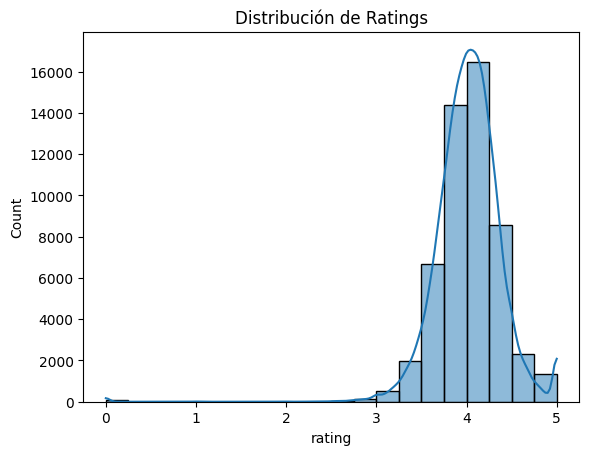

In [84]:
sns.histplot(df['rating'], bins=20, kde=True)
plt.title("Distribución de Ratings")
plt.show()

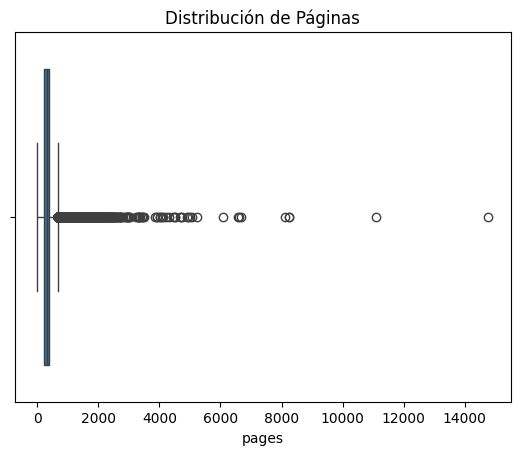

In [90]:
sns.boxplot(x=df['pages'])
plt.title("Distribución de Páginas")
plt.show()

In [94]:
print(df[df['pages'] > 1500][['title', 'pages']].sort_values('pages', ascending=False).head(20))
# Se tratan de boxsets de enciclopedias, diccionarios, etc. No son libros normales, por lo que se hará un subset de libros con menos de 5000 páginas para el análisis:
df_individual = df[df['pages'] <= 4000]

                                                   title    pages
11490                          The Story of Civilization  14777.0
22960                         The Complete Wheel of Time  11095.0
8374             The Complete Malazan Book of the Fallen   8258.0
5098                                           Animorphs   8245.0
20098                                          Homestuck   8124.0
3148                                                Worm   6680.0
23326                                سه تفنگدار: ١٠ جلدی   6600.0
4692      The Complete Aubrey/Maturin Novels (5 Volumes)   6576.0
14269                                   البداية والنهاية   6088.0
1679                              A Song of Ice and Fire   5216.0
38814  One Piece Box Set 3: Thriller Bark to New Worl...   5056.0
27049             Cuentos completos 1880 -1903 [Estuche]   5000.0
38247  One Piece Box Set 2: Skypeia and Water Seven: ...   4936.0
29873                                   Capital D: Adult   4892.0
14949     

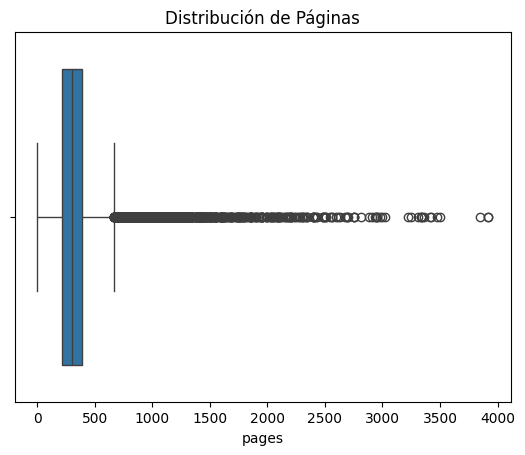

In [95]:
sns.boxplot(x=df_individual['pages'])
plt.title("Distribución de Páginas")
plt.show()

In [97]:
print(df_individual[df_individual['pages'] > 1500][['title', 'pages']].sort_values('pages', ascending=False).head(20))

                                                   title   pages
20281              The House of Night Series: Books 1-12  3920.0
2667   The Dark Tower Series Collection: The Gunsling...  3914.0
23253  The English Bible, King James Version: The Old...  3848.0
28463                                  The Paranormal 13  3500.0
20867                               (قبل از طوفان (8 جلد  3475.0
14920                         Horatio Hornblower 1 - 11.  3420.0
2486                                  The Complete Wreck  3417.0
20850                                       The Omnidoxy  3357.0
2286                             Harry Potter Collection  3342.0
12845                                     Special Forces  3338.0
25360  Beauty Grown From a Concrete Life: Blossoming ...  3337.0
32615                  The Unwanteds Complete Collection  3312.0
8474   The Mortal Instruments, the Complete Collectio...  3248.0
23455         شخصية مصر: دراسة في عبقرية المكان - الوسيط  3224.0
7536                     